Ridge RMSE: 0.8648459768289816
Ridge MAE: 0.6439803696514683

Top 20 Feature Importances:
n_non_stop_unique_tokens        -0.505135
kw_avg_avg                       0.425561
n_non_stop_words                 0.363112
kw_max_avg                      -0.246208
n_unique_tokens                  0.151040
average_token_length            -0.076164
kw_avg_min                      -0.072540
LDA_00                           0.068970
data_channel_is_entertainment   -0.066457
kw_min_min                       0.063033
kw_max_min                       0.061384
kw_min_avg                      -0.058486
rate_positive_words              0.056095
LDA_02                          -0.054426
data_channel_is_bus             -0.052700
global_subjectivity              0.049760
num_hrefs                        0.048211
data_channel_is_tech             0.045720
data_channel_is_socmed           0.043815
is_weekend                       0.042352
dtype: float64


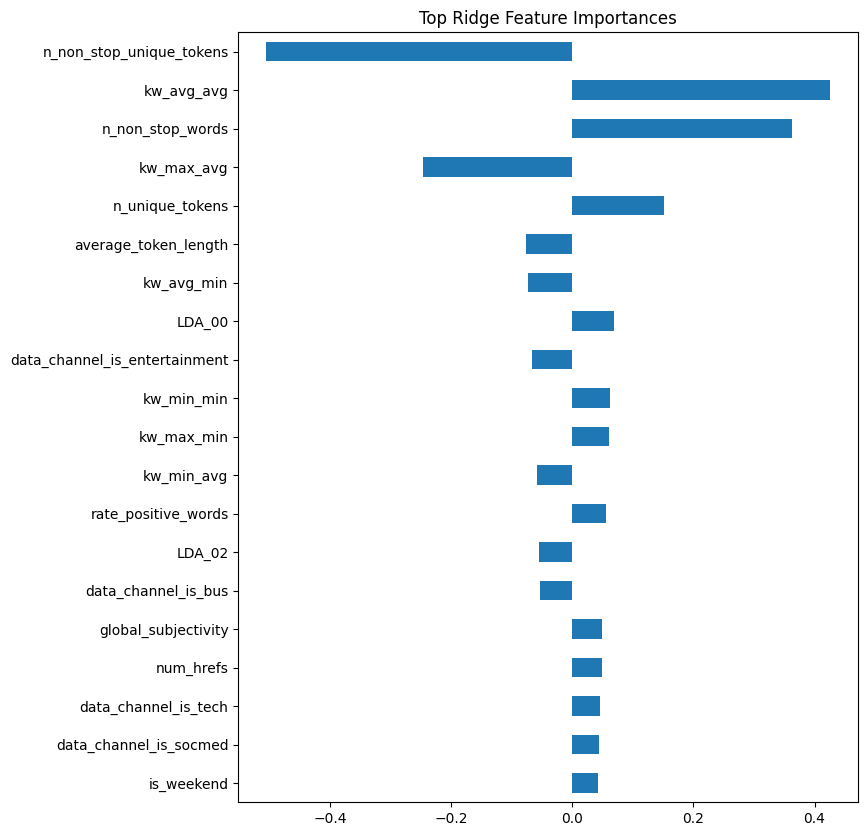

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

df = pd.read_csv("/content/online_news_cleaned.csv")

y = df["log_shares"].to_numpy()
X = df.drop(columns=["shares", "log_shares"])
X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns
X = X.to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred = ridge.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Ridge RMSE:", rmse)
print("Ridge MAE:", mae)

coef = ridge.coef_
importance = pd.Series(coef, index=feature_names).sort_values(key=abs, ascending=False)

print("\nTop 20 Feature Importances:")
print(importance.head(20))

importance.head(20).plot(kind="barh", figsize=(8,10))
plt.title("Top Ridge Feature Importances")
plt.gca().invert_yaxis()
plt.show()


Lasso RMSE: 0.8677198256415566
Lasso MAE: 0.6489220814689253

Top 20 Lasso Feature Importances:
kw_avg_avg                       0.253132
kw_max_avg                      -0.111628
is_weekend                       0.082548
LDA_02                          -0.076628
data_channel_is_entertainment   -0.061627
data_channel_is_socmed           0.052901
data_channel_is_tech             0.047161
kw_min_min                       0.044129
num_hrefs                        0.042770
global_subjectivity              0.032969
average_token_length            -0.030947
num_keywords                     0.030654
self_reference_avg_sharess       0.026767
num_imgs                         0.022810
self_reference_min_shares        0.022802
kw_min_max                      -0.021215
LDA_01                          -0.014035
weekday_is_friday                0.013629
num_self_hrefs                  -0.012898
n_tokens_content                 0.011374
dtype: float64


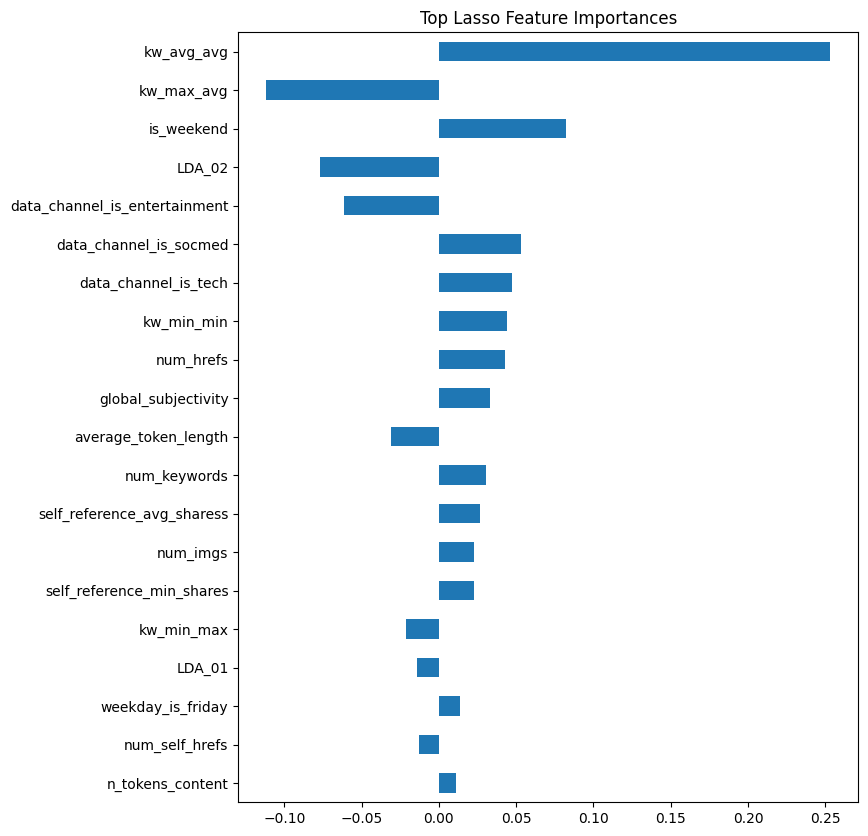

In [4]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


df = pd.read_csv("/content/online_news_cleaned.csv")

y = df["log_shares"].to_numpy()
X = df.drop(columns=["shares", "log_shares"])
X = pd.get_dummies(X, drop_first=True)
feature_names = X.columns
X = X.to_numpy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)

y_pred = lasso.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

print("Lasso RMSE:", rmse)
print("Lasso MAE:", mae)

coef = lasso.coef_
importance = pd.Series(coef, index=feature_names).sort_values(key=abs, ascending=False)

print("\nTop 20 Lasso Feature Importances:")
print(importance.head(20))

importance.head(20).plot(kind="barh", figsize=(8,10))
plt.title("Top Lasso Feature Importances")
plt.gca().invert_yaxis()
plt.show()
